# Análisis de errores por slices y plan de mitigación

## Configuración

In [1]:
import warnings, os, json, re, time
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (f1_score, accuracy_score, precision_score, recall_score,
                             roc_auc_score, confusion_matrix, brier_score_loss,
                             silhouette_score)
import xgboost as xgb
import shap

SEED = 42
np.random.seed(SEED)
plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')
os.makedirs('outputs_sprint4', exist_ok=True)

# ---- Datos y split (identicos a los sprints anteriores) ----
df = pd.read_csv('../data/processed/data_procesada.csv')
EXCLUIR = ['Au_ppm', 'target_Au', 'East', 'North', 'Level']
FEATURES_BASE = [c for c in df.columns if c not in EXCLUIR]
X = df[FEATURES_BASE].copy()
y = df['target_Au'].astype(int).copy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
CV5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# coordenadas y Au reales (SOLO para definir slices, nunca como features)
AUX_TRAIN = df.loc[X_train.index, ['East', 'North', 'Level', 'Au_ppm']]
AUX_TEST = df.loc[X_test.index, ['East', 'North', 'Level', 'Au_ppm']]

# ---- Cargar el veredicto del Sprint 3 (dinamico) ----
with open('outputs_sprint3/final_resumen_sprint3.json') as f:
    RESUMEN_S3 = json.load(f)
with open('outputs_sprint2/resumen_sprint2.json') as f:
    RESUMEN_S2 = json.load(f)
assert RESUMEN_S3['ganador'].startswith('XGBoost'), \
    'El pipeline del Sprint 4 asume XGBoost como ganador del Sprint 3'
print('Modelo final Sprint 3:', RESUMEN_S3['ganador'])
print('Set de features:', RESUMEN_S3['mejor_set_features'], f"({RESUMEN_S3['n_features']} features)")
print('Calibración:', RESUMEN_S3['calibracion'], '| Umbral:', round(RESUMEN_S3['umbral'], 2))
print('F1 final Sprint 3:', RESUMEN_S3['f1_final'])

Modelo final Sprint 3: XGBoost (Mejor set  + params XGB + cluster)
Set de features: Top-26 + cluster XGB (31 features)
Calibración: Isotónica | Umbral: 0.39
F1 final Sprint 3: 0.7429


In [3]:
# ---- Utilidades de clustering (mismas del Sprint 2/3) ----
def elegir_k_clustering(Xsc, ks=range(2, 11)):
    silus = [silhouette_score(Xsc, KMeans(n_clusters=k, random_state=SEED, n_init=10)
                              .fit_predict(Xsc)) for k in ks]
    bics = [GaussianMixture(n_components=k, random_state=SEED, n_init=3).fit(Xsc).bic(Xsc) for k in ks]
    d5 = np.sort(NearestNeighbors(n_neighbors=5).fit(Xsc).kneighbors(Xsc)[0][:, -1])
    return list(ks)[int(np.argmax(silus))], list(ks)[int(np.argmin(bics))], float(np.percentile(d5, 90))

def ajustar_clustering(Xsc_tr, k_km, k_gm, eps):
    km = KMeans(n_clusters=k_km, random_state=SEED, n_init=10).fit(Xsc_tr)
    gm = GaussianMixture(n_components=k_gm, random_state=SEED, n_init=3).fit(Xsc_tr)
    db = DBSCAN(eps=eps, min_samples=5).fit(Xsc_tr)
    nn_core = NearestNeighbors(n_neighbors=1).fit(Xsc_tr[db.core_sample_indices_])
    return km, gm, nn_core

def features_clustering(Xsc, km, gm, nn_core, eps, prefijo=''):
    return pd.DataFrame({
        f'{prefijo}kmeans_label': km.predict(Xsc),
        f'{prefijo}kmeans_dist': km.transform(Xsc).min(axis=1),
        f'{prefijo}gmm_label': gm.predict(Xsc),
        f'{prefijo}gmm_prob_max': gm.predict_proba(Xsc).max(axis=1),
        f'{prefijo}dbscan_outlier': (nn_core.kneighbors(Xsc)[0][:, 0] > eps).astype(int)})

# ranking SHAP del Sprint 3 (elementos originales)
imp_shap = pd.read_csv('outputs_sprint3/xgb_cluster_shap_importancias.csv', index_col=0)['shap_medio']
RANKING_ELEMENTOS = [f for f in imp_shap.sort_values(ascending=False).index if f in FEATURES_BASE]

set_s3 = RESUMEN_S3['mejor_set_features']
m = re.search(r'Top-(\d+)', set_s3)
N_TOP = int(m.group(1)) if m else None
ELS = RANKING_ELEMENTOS[:N_TOP] if N_TOP else FEATURES_BASE

if 'refinado' in set_s3:
    # clustering refinado: sobre los top-N elementos
    SC_ = StandardScaler().fit(X_train[ELS])
    k_km, k_gm, eps = elegir_k_clustering(SC_.transform(X_train[ELS]))
    KM_, GM_, NN_ = ajustar_clustering(SC_.transform(X_train[ELS]), k_km, k_gm, eps)
    CLU_TRAIN = features_clustering(SC_.transform(X_train[ELS]), KM_, GM_, NN_, eps, 'ref_').set_index(X_train.index)
    CLU_TEST = features_clustering(SC_.transform(X_test[ELS]), KM_, GM_, NN_, eps, 'ref_').set_index(X_test.index)
    COL_KMEANS = 'ref_kmeans_label'
else:
    # clustering del Sprint 2: sobre los 46 elementos
    SC_ = StandardScaler().fit(X_train)
    k_km, k_gm, eps = elegir_k_clustering(SC_.transform(X_train))
    KM_, GM_, NN_ = ajustar_clustering(SC_.transform(X_train), k_km, k_gm, eps)
    CLU_TRAIN = features_clustering(SC_.transform(X_train), KM_, GM_, NN_, eps).set_index(X_train.index)
    CLU_TEST = features_clustering(SC_.transform(X_test), KM_, GM_, NN_, eps).set_index(X_test.index)
    COL_KMEANS = 'kmeans_label'

XTR_FINAL = pd.concat([X_train[ELS], CLU_TRAIN], axis=1)
XTE_FINAL = pd.concat([X_test[ELS], CLU_TEST], axis=1)
assert XTR_FINAL.shape[1] == RESUMEN_S3['n_features'], \
    f"Reconstrucción inconsistente: {XTR_FINAL.shape[1]} vs {RESUMEN_S3['n_features']} features"
print(f'Set reconstruido: {XTR_FINAL.shape[1]} features ({set_s3}) | KMeans k={k_km}')

Set reconstruido: 31 features (Top-26 + cluster XGB) | KMeans k=4


In [7]:
# hiperparametros segun la configuracion ganadora del Sprint 3
if 'CV-repetida' in RESUMEN_S3['ganador']:
    with open('outputs_sprint3/optuna_rcv_best_params.json') as f:
        PARAMS = json.load(f)
elif RESUMEN_S2['config_final'] == '+ Optuna':
    with open('outputs_sprint2/optuna_best_params.json') as f:
        PARAMS = json.load(f)['XGBoost']
else:
    SPW = float((y_train == 0).sum() / (y_train == 1).sum())
    PARAMS = {'n_estimators': 100, 'scale_pos_weight': SPW}

def xgb_final():
    return xgb.XGBClassifier(random_state=SEED, eval_metric='logloss', tree_method='hist',
                             n_jobs=-1, **PARAMS)

def modelo_final():
    '''XGBoost + la calibracion elegida en el Sprint 3.'''
    cal = RESUMEN_S3['calibracion']
    if cal == 'Sin calibrar':
        return xgb_final()
    metodo = 'sigmoid' if 'Sigmoid' in cal else 'isotonic'
    return CalibratedClassifierCV(xgb_final(), method=metodo, cv=CV5)

UMBRAL = float(RESUMEN_S3['umbral'])
CLF_BASE = modelo_final().fit(XTR_FINAL, y_train)
prob_test = CLF_BASE.predict_proba(XTE_FINAL)[:, 1]
pred_test = (prob_test >= UMBRAL).astype(int)

# probabilidades out-of-fold en train (para decisiones de mitigacion sin tocar el hold-out)
prob_oof = cross_val_predict(modelo_final(), XTR_FINAL, y_train, cv=CV5,
                             method='predict_proba', n_jobs=-1)[:, 1]

def metricas(y_true, pred, prob):
    return {'F1': f1_score(y_true, pred), 'Accuracy': accuracy_score(y_true, pred),
            'Precision': precision_score(y_true, pred, zero_division=0),
            'Recall': recall_score(y_true, pred), 'AUC-ROC': roc_auc_score(y_true, prob),
            'Brier': brier_score_loss(y_true, prob)}

MET_BASE = metricas(y_test, pred_test, prob_test)
F1_GLOBAL = MET_BASE['F1']
print(f'Modelo final reconstruido — F1 hold-out = {F1_GLOBAL:.4f} '
      f'(Sprint 3 reportó {RESUMEN_S3["f1_final"]})')
for k, v in MET_BASE.items():
    print(f'  {k}: {v:.4f}')

Modelo final reconstruido — F1 hold-out = 0.7429 (Sprint 3 reportó 0.7429)
  F1: 0.7429
  Accuracy: 0.9368
  Precision: 0.7358
  Recall: 0.7500
  AUC-ROC: 0.9625
  Brier: 0.0443


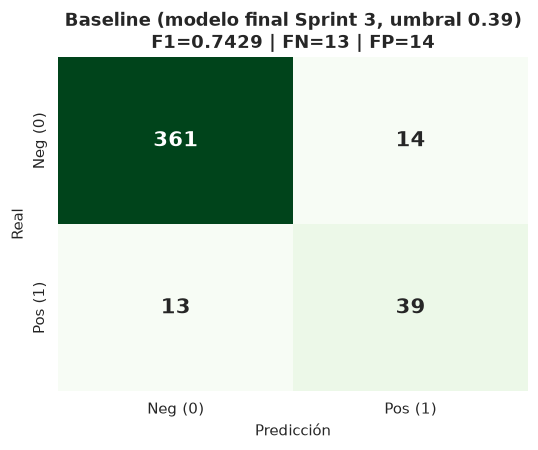

In [9]:
cm = confusion_matrix(y_test, pred_test)
fig, ax = plt.subplots(figsize=(5, 4.2))
sns.heatmap(cm, annot=True, fmt='d', cbar=False, cmap='Greens',
            xticklabels=['Neg (0)', 'Pos (1)'], yticklabels=['Neg (0)', 'Pos (1)'],
            annot_kws={'size': 14, 'fontweight': 'bold'})
ax.set_xlabel('Predicción'); ax.set_ylabel('Real')
ax.set_title(f'Baseline (modelo final Sprint 3, umbral {UMBRAL:.2f})\n'
             f'F1={F1_GLOBAL:.4f} | FN={cm[1,0]} | FP={cm[0,1]}', fontweight='bold')
plt.tight_layout(); plt.savefig('outputs_sprint4/matriz_baseline.png', bbox_inches='tight'); plt.show()

## Definición de slices

10 slices en 4 familias. Las variables `East/North/Level/Au_ppm` **no son features del modelo** —
se usan únicamente para particionar el hold-out y analizar dónde falla.

| # | Slice | Familia | Justificación |
|---|---|---|---|
| 1 | Cuadrante (NE/NO/SE/SO) | Espacial | Variabilidad geográfica |
| 2 | Profundidad (terciles de Level) | Espacial | Comportamiento vertical |
| 3 | Ag_ppm (terciles) | Geoquímica | Pathfinder principal (SHAP #1) |
| 4 | As_ppm (terciles) | Geoquímica | Pathfinder clásico de Au (SHAP top-5) |
| 5 | S_per (terciles) | Geoquímica | Mineralización sulfurosa |
| 6 | Fe_per (terciles) | Geoquímica | Alteración / oxidación |
| 7 | Distancia al umbral de Au (frontera 0.05–0.15 ppm) | Target | Zona de incertidumbre de la definición del target |
| 8 | Cluster KMeans (del modelo) | Dominio | ¿Rinde igual en todos los dominios geoquímicos? |
| 9 | Confianza del modelo (prob) | Modelo | Autocrítica de las probabilidades |
| 10 | Tipo de error (TP/FP/FN/TN) | Modelo | Anatomía de los errores |

Los cortes (medianas/terciles) se calculan **en train** y se aplican al test — el análisis no
adapta sus definiciones al hold-out.

In [10]:
def construir_slices(Xf, aux, prob, pred, y_true, cortes=None):
    '''Construye el dataframe de slices. Los cortes se calculan en train si no se pasan.'''
    S = pd.DataFrame(index=Xf.index)
    S['y_true'], S['y_pred'], S['y_prob'] = y_true.values, pred, prob
    c = cortes or {}

    # 1) cuadrante espacial
    c.setdefault('east_med', aux['East'].median()); c.setdefault('north_med', aux['North'].median())
    S['slice_cuadrante'] = np.where(aux['East'] >= c['east_med'],
                                    np.where(aux['North'] >= c['north_med'], 'NE', 'SE'),
                                    np.where(aux['North'] >= c['north_med'], 'NO', 'SO'))
    # 2) profundidad (Level bajo = profundo)
    c.setdefault('lq33', aux['Level'].quantile(0.33)); c.setdefault('lq66', aux['Level'].quantile(0.66))
    S['slice_profundidad'] = np.where(aux['Level'] <= c['lq33'], 'Profundo',
                             np.where(aux['Level'] <= c['lq66'], 'Medio', 'Superficial'))
    # 3-6) geoquimicos (terciles calculados en train, pasados via `cortes`)
    for el, nombre in [('Ag_ppm', 'ag'), ('As_ppm', 'as'), ('S_per', 's'), ('Fe_per', 'fe')]:
        q33, q66 = c[f'{nombre}_q33'], c[f'{nombre}_q66']
        v = df.loc[Xf.index, el]
        S[f'slice_{nombre}'] = np.where(v <= q33, f'Bajo_{nombre.upper()}',
                               np.where(v <= q66, f'Medio_{nombre.upper()}', f'Alto_{nombre.upper()}'))
    # 7) distancia al umbral del target (Au_ppm real)
    au = aux['Au_ppm']
    S['slice_frontera'] = np.select(
        [au < 0.01, (au >= 0.05) & (au <= 0.15), au > 0.50],
        ['Lejos_negativo', 'Frontera_0.05-0.15', 'Lejos_positivo'], default='Resto')
    # 8) cluster kmeans del modelo
    S['slice_cluster'] = 'C' + pd.Series(
        (CLU_TRAIN if Xf.index.equals(X_train.index) else CLU_TEST)[COL_KMEANS].values,
        index=Xf.index).astype(str)
    # 9) confianza del modelo
    S['slice_confianza'] = np.where(prob < 0.3, 'Baja_conf',
                           np.where(prob < 0.7, 'Media_conf', 'Alta_conf'))
    # 10) tipo de error
    S['slice_error'] = np.select(
        [(S.y_true == 1) & (S.y_pred == 1), (S.y_true == 0) & (S.y_pred == 1),
         (S.y_true == 1) & (S.y_pred == 0)], ['TP', 'FP', 'FN'], default='TN')
    return S, c

# cortes de terciles geoquimicos calculados EN TRAIN
CORTES = {}
for el, nombre in [('Ag_ppm', 'ag'), ('As_ppm', 'as'), ('S_per', 's'), ('Fe_per', 'fe')]:
    CORTES[f'{nombre}_q33'] = df.loc[X_train.index, el].quantile(0.33)
    CORTES[f'{nombre}_q66'] = df.loc[X_train.index, el].quantile(0.66)
CORTES['east_med'] = AUX_TRAIN['East'].median(); CORTES['north_med'] = AUX_TRAIN['North'].median()
CORTES['lq33'] = AUX_TRAIN['Level'].quantile(0.33); CORTES['lq66'] = AUX_TRAIN['Level'].quantile(0.66)

pred_train_oof = (prob_oof >= UMBRAL).astype(int)
SL_TRAIN, _ = construir_slices(X_train, AUX_TRAIN, prob_oof, pred_train_oof, y_train, CORTES)
SL_TEST, _ = construir_slices(X_test, AUX_TEST, prob_test, pred_test, y_test, CORTES)
COLS_SLICE = [col for col in SL_TEST.columns if col.startswith('slice_')]
print(f'Slices construidos: {len(COLS_SLICE)}')

# resumen de composicion (test)
rows = []
for col in COLS_SLICE:
    for cat, g in SL_TEST.groupby(col):
        rows.append({'Slice': col.replace('slice_', ''), 'Categoría': cat,
                     'n': len(g), 'positivos': int(g.y_true.sum()),
                     '% positivos': round(g.y_true.mean(), 3)})
tabla_comp = pd.DataFrame(rows)
tabla_comp.to_csv('outputs_sprint4/composicion_slices.csv', index=False)
display(tabla_comp)

Slices construidos: 10


,Slice,Categoría,n,positivos,% positivos
0,cuadrante,NE,113,12,0.106
1,cuadrante,NO,95,13,0.137
2,cuadrante,SE,107,6,0.056
3,cuadrante,SO,112,21,0.188
4,profundidad,Medio,130,23,0.177
5,profundidad,Profundo,144,17,0.118
6,profundidad,Superficial,153,12,0.078
7,ag,Alto_AG,145,52,0.359
8,ag,Bajo_AG,149,0,0.000
9,ag,Medio_AG,133,0,0.000


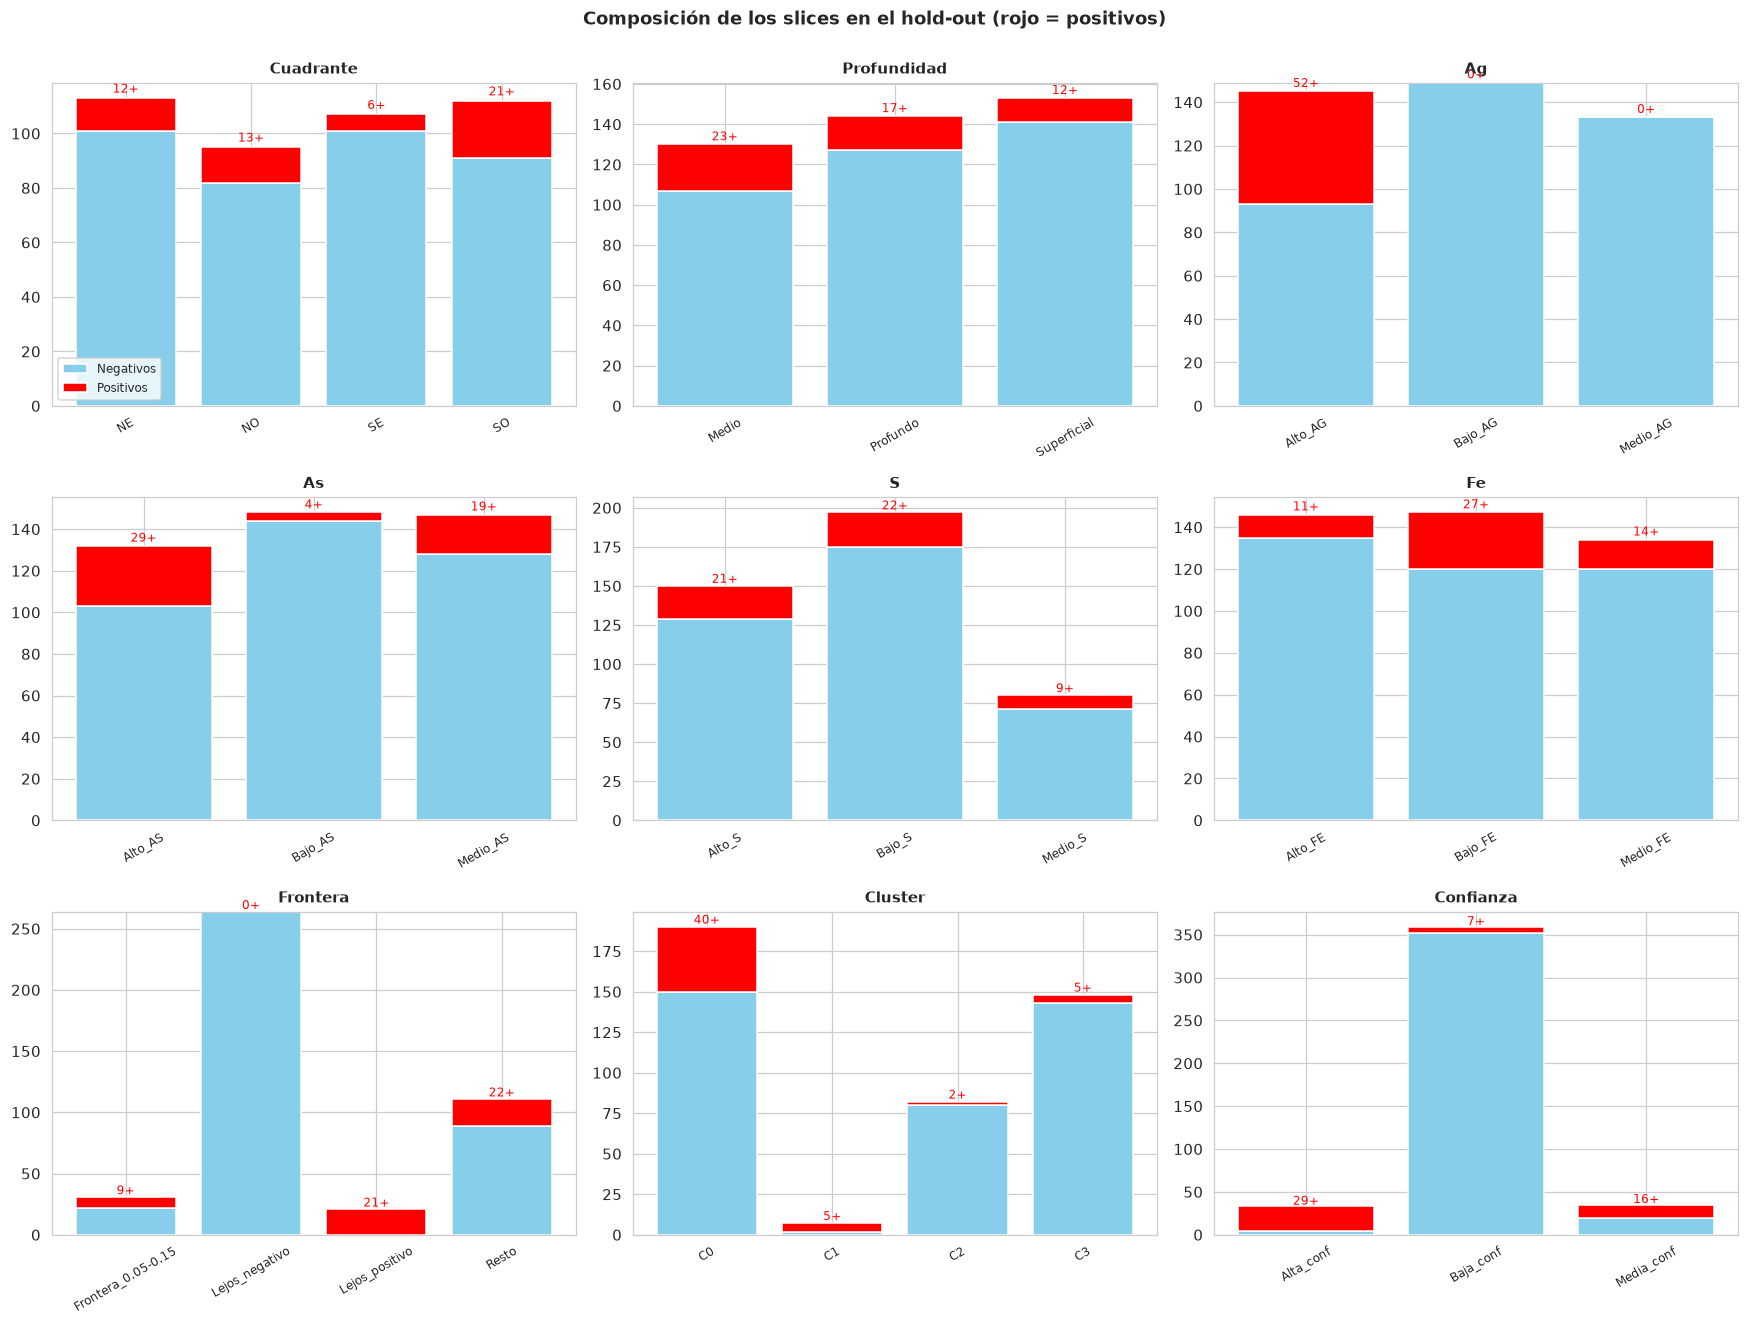

In [18]:
slices_plot = [c for c in COLS_SLICE if c != 'slice_error']
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
for ax, col in zip(axes.ravel(), slices_plot):
    g = SL_TEST.groupby(col).agg(n=('y_true', 'size'), pos=('y_true', 'sum'))
    g = g.sort_index()
    ax.bar(g.index, g['n'] - g['pos'], color='skyblue', label='Negativos')
    ax.bar(g.index, g['pos'], bottom=g['n'] - g['pos'], color='red', label='Positivos')
    for i, (cat, r) in enumerate(g.iterrows()):
        ax.text(i, r['n'] + 2, f"{int(r['pos'])}+", ha='center', fontsize=8, color='red')
    ax.set_title(col.replace('slice_', '').capitalize(), fontweight='bold', fontsize=10)
    ax.tick_params(axis='x', rotation=30, labelsize=8)
axes[0, 0].legend(fontsize=8)
plt.suptitle('Composición de los slices en el hold-out (rojo = positivos)',
             fontweight='bold', y=1.0)
plt.tight_layout(); plt.savefig('outputs_sprint4/composicion_slices.png', bbox_inches='tight'); plt.show()

## Métricas por slice con intervalos de confianza (boostrap)

In [12]:
RNG = np.random.default_rng(SEED)
def bootstrap_f1(y_true, y_pred, n_boot=1000):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    f1s = []
    n = len(y_true)
    for _ in range(n_boot):
        idx = RNG.integers(0, n, n)
        if y_true[idx].sum() == 0: continue        # sin positivos, F1 indefinido
        f1s.append(f1_score(y_true[idx], y_pred[idx], zero_division=0))
    if not f1s: return np.nan, np.nan
    return float(np.percentile(f1s, 2.5)), float(np.percentile(f1s, 97.5))

rows = []
for col in COLS_SLICE:
    if col == 'slice_error': continue      # TP/FP/FN/TN no tiene F1 propio
    for cat, g in SL_TEST.groupby(col):
        n, npos = len(g), int(g.y_true.sum())
        if npos == 0:
            f1 = np.nan; lo = hi = np.nan; rec = np.nan; prec = np.nan
        else:
            f1 = f1_score(g.y_true, g.y_pred, zero_division=0)
            rec = recall_score(g.y_true, g.y_pred, zero_division=0)
            prec = precision_score(g.y_true, g.y_pred, zero_division=0)
            lo, hi = bootstrap_f1(g.y_true.values, g.y_pred.values)
        rows.append({'Slice': col.replace('slice_', ''), 'Categoría': cat, 'n': n,
                     'positivos': npos, 'F1': round(f1, 4) if f1 == f1 else np.nan,
                     'IC95_inf': round(lo, 4) if lo == lo else np.nan,
                     'IC95_sup': round(hi, 4) if hi == hi else np.nan,
                     'Precision': round(prec, 4) if prec == prec else np.nan,
                     'Recall': round(rec, 4) if rec == rec else np.nan,
                     'Δ F1 vs global': round(f1 - F1_GLOBAL, 4) if f1 == f1 else np.nan})
tabla_slices = pd.DataFrame(rows)
tabla_slices.to_csv('outputs_sprint4/metricas_por_slice.csv', index=False)
display(tabla_slices)

,Slice,Categoría,n,positivos,F1,IC95_inf,IC95_sup,Precision,Recall,Δ F1 vs global
0,cuadrante,NE,113,12,0.5833,0.3000,0.7857,0.5833,0.5833,-0.1595
1,cuadrante,NO,95,13,0.9231,0.7825,1.0000,0.9231,0.9231,0.1802
2,cuadrante,SE,107,6,0.4706,0.1333,0.7280,0.3636,0.6667,-0.2723
3,cuadrante,SO,112,21,0.8421,0.7059,0.9524,0.9412,0.7619,0.0992
4,profundidad,Medio,130,23,0.9091,0.8075,0.9796,0.9524,0.8696,0.1662
5,profundidad,Profundo,144,17,0.7742,0.5832,0.9231,0.8571,0.7059,0.0313
6,profundidad,Superficial,153,12,0.4667,0.2143,0.6667,0.3889,0.5833,-0.2762
7,ag,Alto_AG,145,52,0.7429,0.6428,0.8305,0.7358,0.7500,0.0000
8,ag,Bajo_AG,149,0,NaN,NaN,NaN,NaN,NaN,NaN
9,ag,Medio_AG,133,0,NaN,NaN,NaN,NaN,NaN,NaN


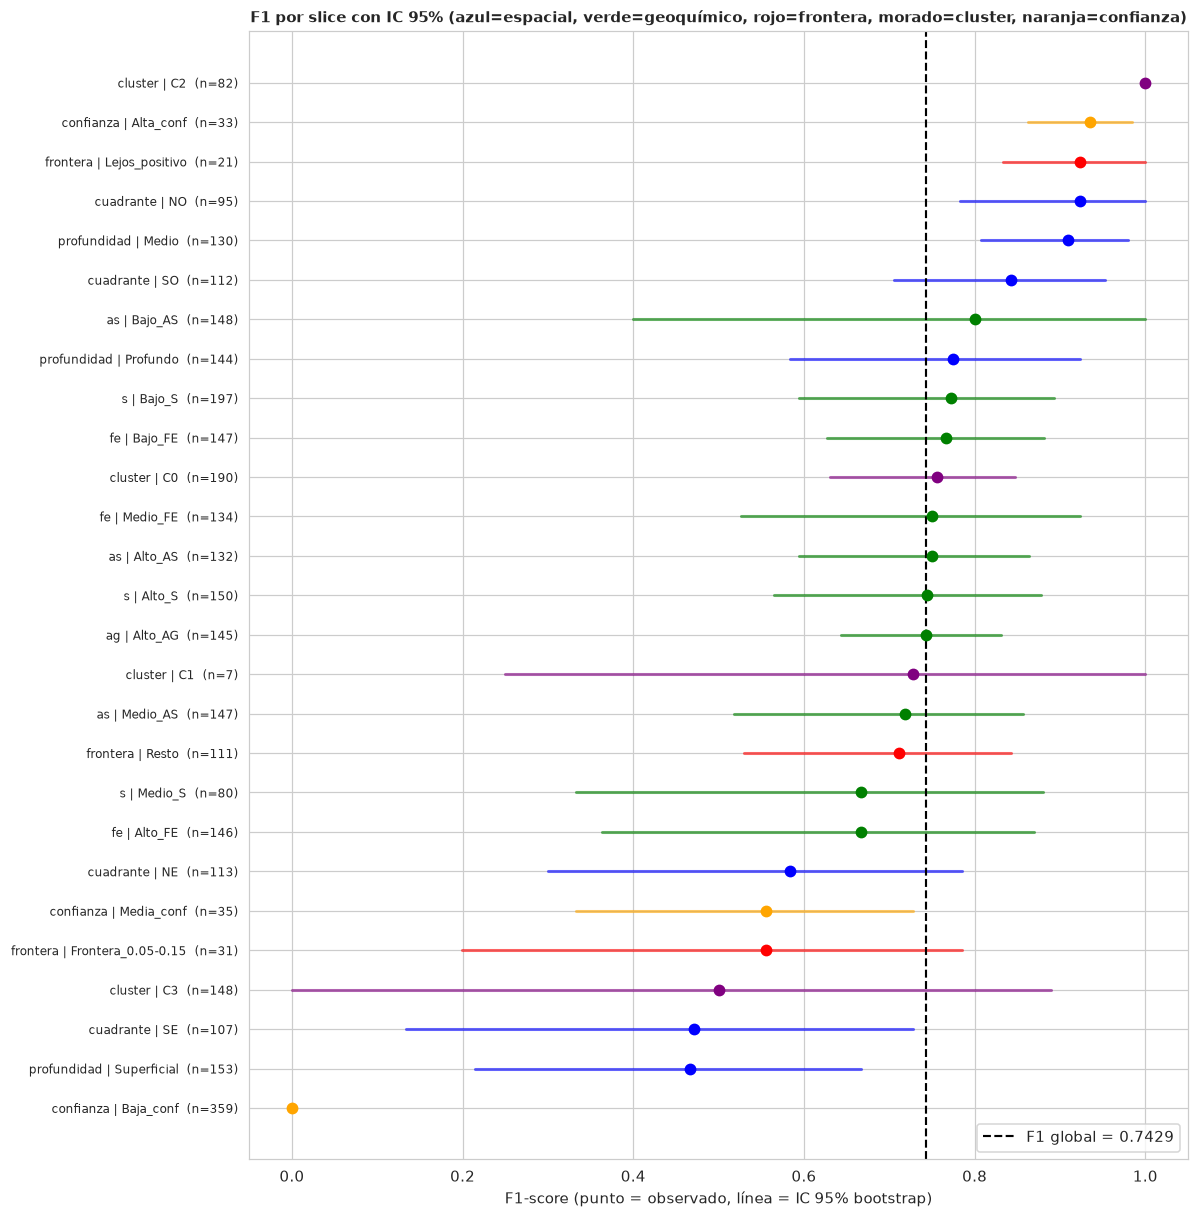

In [19]:
tp = tabla_slices.dropna(subset=['F1']).copy()
tp['etiqueta'] = tp['Slice'] + ' | ' + tp['Categoría'] + '  (n=' + tp['n'].astype(str) + ')'
tp = tp.sort_values('F1')

fig, ax = plt.subplots(figsize=(11, 0.34 * len(tp) + 2))
colores_familia = {'cuadrante': 'blue', 'profundidad': 'blue',
                   'ag': 'green', 'as': 'green', 's': 'green', 'fe': 'green',
                   'frontera': 'red', 'cluster': 'purple', 'confianza': 'orange'}
for i, (_, r) in enumerate(tp.iterrows()):
    color = colores_familia.get(r['Slice'], 'gray')
    ax.plot([r['IC95_inf'], r['IC95_sup']], [i, i], color=color, lw=2, alpha=0.6)
    ax.scatter([r['F1']], [i], color=color, s=45, zorder=5)
ax.axvline(F1_GLOBAL, ls='--', color='black', lw=1.4, label=f'F1 global = {F1_GLOBAL:.4f}')
ax.set_yticks(range(len(tp))); ax.set_yticklabels(tp['etiqueta'], fontsize=8)
ax.set_xlabel('F1-score (punto = observado, línea = IC 95% bootstrap)')
ax.set_title('F1 por slice con IC 95% (azul=espacial, verde=geoquímico, '
             'rojo=frontera, morado=cluster, naranja=confianza)', fontweight='bold', fontsize=10)
ax.legend(loc='lower right')
plt.tight_layout(); plt.savefig('outputs_sprint4/forest_plot_f1.png', bbox_inches='tight'); plt.show()

## Slices problemáticos

In [15]:
cand = tabla_slices.dropna(subset=['F1']).copy()
cand = cand[(cand['n'] >= 30) & (cand['positivos'] >= 5)]
cand['significativo'] = cand['IC95_sup'] < F1_GLOBAL
problematicos = cand[cand['F1'] < F1_GLOBAL].sort_values('Δ F1 vs global')

ACCIONABLES = ['cuadrante', 'profundidad', 'ag', 'as', 's', 'fe', 'cluster']
prob_accionables = problematicos[problematicos['Slice'].isin(ACCIONABLES)]

print(f'Slices con caída de F1 (n≥30, pos≥5): {len(problematicos)}')
print(f'  De ellos, estadísticamente significativos (IC no cruza el global): '
      f'{problematicos["significativo"].sum()}')
display(problematicos)

# top-2 problematicos ACCIONABLES para la mitigacion
TOP2 = prob_accionables.head(2).reset_index(drop=True)
problematicos.to_csv('outputs_sprint4/slices_problematicos.csv', index=False)
print('\nTop-2 slices problemáticos accionables (objetivo de la mitigación):')
display(TOP2[['Slice', 'Categoría', 'n', 'positivos', 'F1', 'IC95_inf', 'IC95_sup',
              'Recall', 'Δ F1 vs global', 'significativo']])

Slices con caída de F1 (n≥30, pos≥5): 11
  De ellos, estadísticamente significativos (IC no cruza el global): 4


,Slice,Categoría,n,positivos,F1,IC95_inf,IC95_sup,Precision,Recall,Δ F1 vs global,significativo
28,confianza,Baja_conf,359,7,0.0000,0.0000,0.0000,0.0000,0.0000,-0.7429,True
6,profundidad,Superficial,153,12,0.4667,0.2143,0.6667,0.3889,0.5833,-0.2762,True
2,cuadrante,SE,107,6,0.4706,0.1333,0.7280,0.3636,0.6667,-0.2723,True
26,cluster,C3,148,5,0.5000,0.0000,0.8889,0.6667,0.4000,-0.2429,False
19,frontera,Frontera_0.05-0.15,31,9,0.5556,0.1995,0.7857,0.5556,0.5556,-0.1873,False
29,confianza,Media_conf,35,16,0.5556,0.3331,0.7274,0.5000,0.6250,-0.1873,True
0,cuadrante,NE,113,12,0.5833,0.3000,0.7857,0.5833,0.5833,-0.1595,False
16,fe,Alto_FE,146,11,0.6667,0.3636,0.8696,0.7000,0.6364,-0.0762,False
15,s,Medio_S,80,9,0.6667,0.3333,0.8802,0.6667,0.6667,-0.0762,False
22,frontera,Resto,111,22,0.7111,0.5293,0.8421,0.6957,0.7273,-0.0317,False



Top-2 slices problemáticos accionables (objetivo de la mitigación):


,Slice,Categoría,n,positivos,F1,IC95_inf,IC95_sup,Recall,Δ F1 vs global,significativo
0,profundidad,Superficial,153,12,0.4667,0.2143,0.6667,0.5833,-0.2762,True
1,cuadrante,SE,107,6,0.4706,0.1333,0.7280,0.6667,-0.2723,True


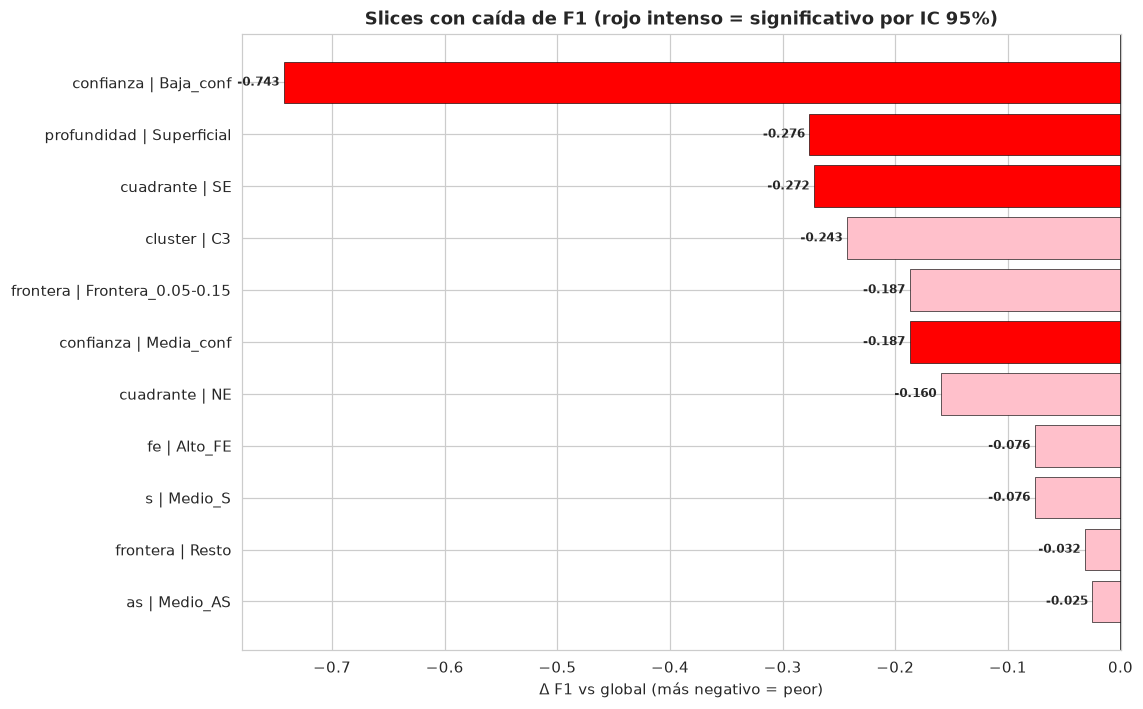

In [20]:
dp = problematicos.copy()
dp['etiqueta'] = dp['Slice'] + ' | ' + dp['Categoría']
fig, ax = plt.subplots(figsize=(10.5, 0.45 * len(dp) + 1.6))
cols = ['red' if s else 'pink' for s in dp['significativo']]
ax.barh(dp['etiqueta'], dp['Δ F1 vs global'], color=cols, edgecolor='black', lw=0.4)
for i, (_, r) in enumerate(dp.iterrows()):
    ax.text(r['Δ F1 vs global'] - 0.004, i, f"{r['Δ F1 vs global']:+.3f}",
            va='center', ha='right', fontsize=8, fontweight='bold')
ax.axvline(0, color='black', lw=1)
ax.set_xlabel('Δ F1 vs global (más negativo = peor)')
ax.set_title('Slices con caída de F1 (rojo intenso = significativo por IC 95%)',
             fontweight='bold')
ax.invert_yaxis()
plt.tight_layout(); plt.savefig('outputs_sprint4/caida_f1.png', bbox_inches='tight'); plt.show()

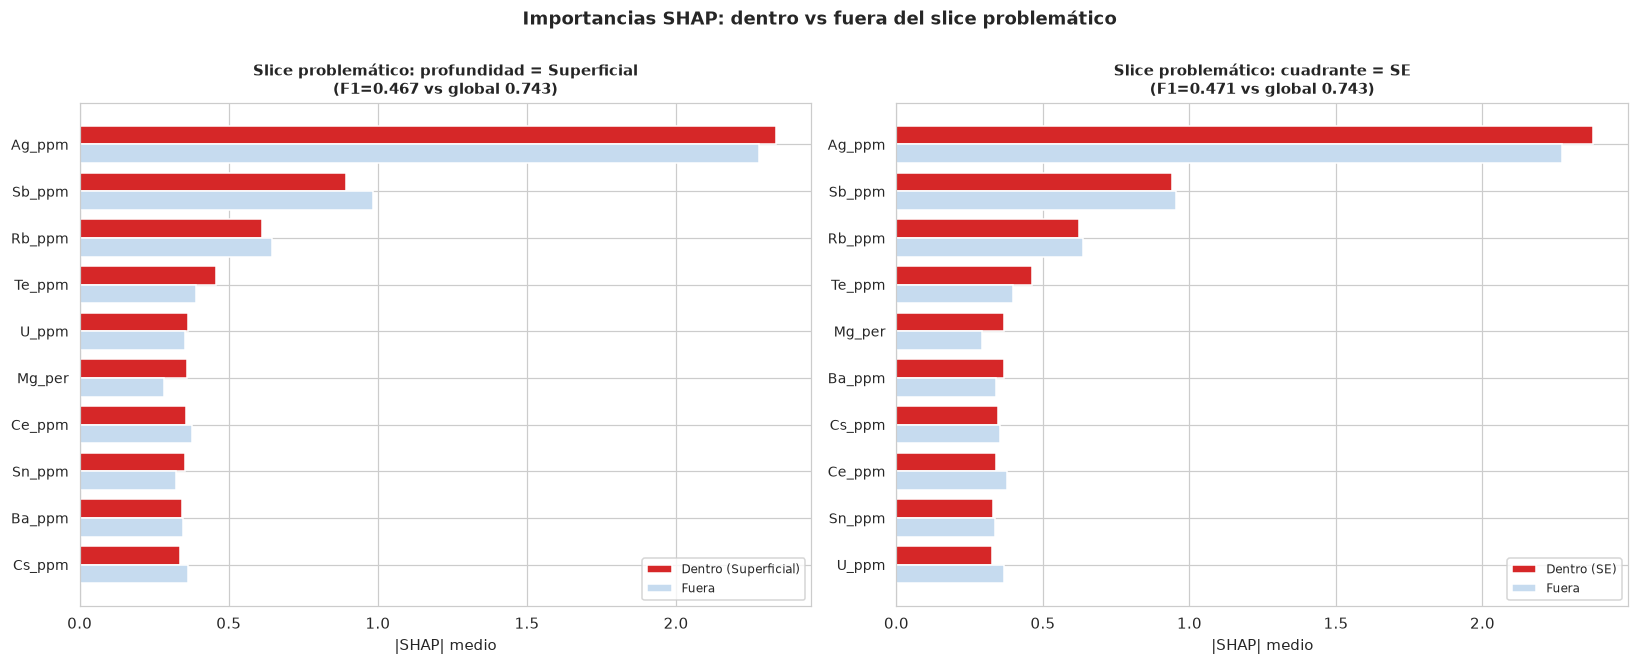

In [22]:
# SHAP sobre el XGBoost puro (la calibracion es monotona: no cambia el orden de las contribuciones)
XGB_RAW = xgb_final().fit(XTR_FINAL, y_train)
explainer = shap.TreeExplainer(XGB_RAW)
sv_test = explainer(XTE_FINAL)
shap_abs = pd.DataFrame(np.abs(sv_test.values), columns=XTE_FINAL.columns, index=XTE_FINAL.index)

fig, axes = plt.subplots(1, max(len(TOP2), 1), figsize=(7.5 * max(len(TOP2), 1), 6))
axes = np.atleast_1d(axes)
for ax, (_, r) in zip(axes, TOP2.iterrows()):
    scol, cat = f"slice_{r['Slice']}", r['Categoría']
    mask = (SL_TEST[scol] == cat).values
    dentro = shap_abs[mask].mean().sort_values(ascending=False).head(10)
    fuera = shap_abs[~mask].mean()[dentro.index]
    yy = np.arange(len(dentro))
    ax.barh(yy - 0.2, dentro.values, height=0.4, color='#d62728', label=f'Dentro ({cat})')
    ax.barh(yy + 0.2, fuera.values, height=0.4, color='#c6dbef', label='Fuera')
    ax.set_yticks(yy); ax.set_yticklabels(dentro.index, fontsize=9)
    ax.invert_yaxis(); ax.set_xlabel('|SHAP| medio')
    ax.set_title(f"Slice problemático: {r['Slice']} = {cat}\n(F1={r['F1']:.3f} vs global {F1_GLOBAL:.3f})",
                 fontweight='bold', fontsize=10)
    ax.legend(fontsize=8)
plt.suptitle('Importancias SHAP: dentro vs fuera del slice problemático',
             fontweight='bold', y=1.0)
plt.tight_layout(); plt.savefig('outputs_sprint4/shap_slices.png', bbox_inches='tight'); plt.show()

Falsos negativos en el slice "profundidad = Superficial": 5

— Muestra 1767: Au real = 0.9980 ppm (positiva), prob = 0.370 < umbral 0.39 → FN


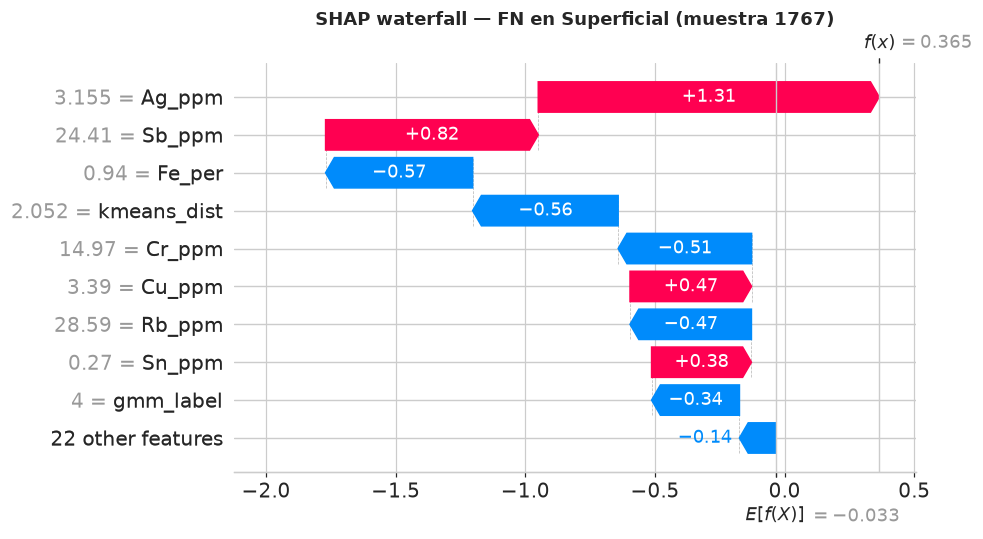


— Muestra 1249: Au real = 0.1350 ppm (positiva), prob = 0.032 < umbral 0.39 → FN


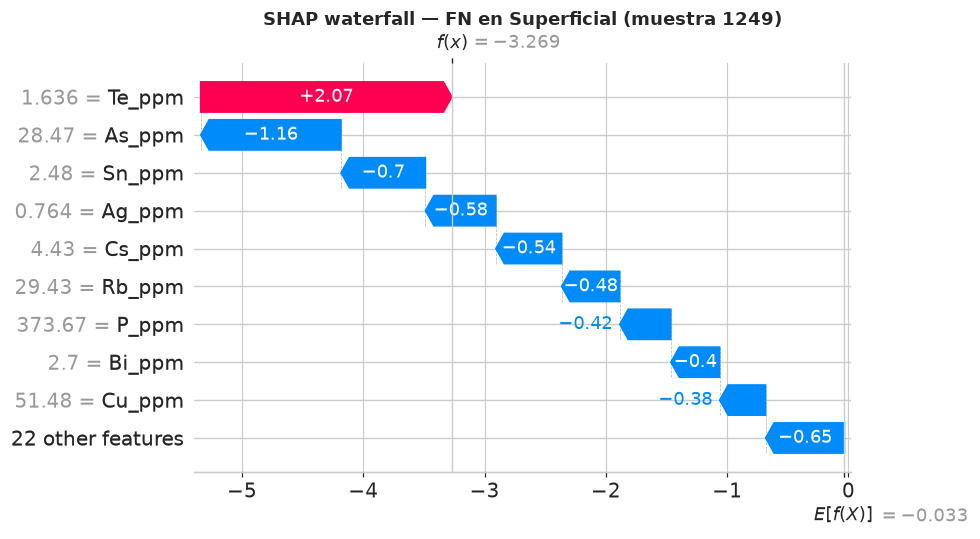

In [23]:
# falsos negativos dentro del primer slice problematico (los errores mas costosos en exploracion)
if len(TOP2) > 0:
    scol, cat = f"slice_{TOP2.iloc[0]['Slice']}", TOP2.iloc[0]['Categoría']
    fn_mask = (SL_TEST[scol] == cat) & (SL_TEST['slice_error'] == 'FN')
    idx_fns = SL_TEST[fn_mask].index[:2]
    print(f'Falsos negativos en el slice "{TOP2.iloc[0]["Slice"]} = {cat}": {fn_mask.sum()}')
    for idx in idx_fns:
        pos = XTE_FINAL.index.get_loc(idx)
        print(f'\n— Muestra {idx}: Au real = {AUX_TEST.loc[idx, "Au_ppm"]:.4f} ppm (positiva), '
              f'prob = {SL_TEST.loc[idx, "y_prob"]:.3f} < umbral {UMBRAL:.2f} → FN')
        shap.plots.waterfall(sv_test[pos], max_display=10, show=False)
        plt.gcf().set_size_inches(9, 5)
        plt.title(f'SHAP waterfall — FN en {cat} (muestra {idx})', fontweight='bold')
        plt.tight_layout()
        plt.savefig(f'outputs_sprint4/waterfall_fn_{idx}.png', bbox_inches='tight'); plt.show()
else:
    print('No hay slices problemáticos accionables → no hay FNs que disecar')

## Diseño de mitigaciones

| # | Mitigación | Descripción | Racional |
|---|---|---|---|
| A | **Umbral por slice** | Umbral óptimo por categoría del slice problemático, elegido con probabilidades **out-of-fold en train** | Si el slice tiene bajo recall, un umbral menor recupera positivos sin re-entrenar |
| B | **Sample weight por slice** | Re-entrenar dando peso 3× a las muestras de train de los slices problemáticos | Enfoca el aprendizaje del modelo en las zonas donde falla |
| C | **Umbral global re-optimizado** | Umbral único que maximiza F1 en OOF (referencia: ¿la mitigación por slice aporta sobre lo global?) | Control del experimento |

**Criterio de éxito:** mejorar el F1 de los slices problemáticos **sin degradar el F1 global en
más de 0.01**. Todas las decisiones (umbrales, pesos) se toman con train/OOF; el hold-out se usa
solo para la evaluación final.

In [24]:
# diagnostico por slice problematico → mitigacion sugerida
mit_rows = []
for _, r in TOP2.iterrows():
    d, a = [], []
    if r['Recall'] < 0.85: d.append(f"Bajo recall ({r['Recall']:.3f})"); a.append('Umbral menor / sample weight')
    if r['Precision'] < 0.85: d.append(f"Baja precisión ({r['Precision']:.3f})"); a.append('Umbral mayor')
    mit_rows.append({'Slice': f"{r['Slice']} = {r['Categoría']}", 'F1': r['F1'],
                     'Diagnóstico': ' | '.join(d) if d else 'OK',
                     'Mitigación sugerida': ' + '.join(a) if a else 'Ninguna'})
df_mit = pd.DataFrame(mit_rows)
df_mit.to_csv('outputs_sprint4/plan_mitigacion.csv', index=False)
display(df_mit)

,Slice,F1,Diagnóstico,Mitigación sugerida
0,profundidad = Superficial,0.4667,Bajo recall (0.583) | Baja precisión (0.389),Umbral menor / sample weight + Umbral mayor
1,cuadrante = SE,0.4706,Bajo recall (0.667) | Baja precisión (0.364),Umbral menor / sample weight + Umbral mayor


In [25]:
def buscar_umbral(y_true, prob):
    umb = np.arange(0.05, 0.95, 0.01)
    f1s = [f1_score(y_true, (prob >= u).astype(int), zero_division=0) for u in umb]
    return float(umb[int(np.argmax(f1s))]), max(f1s)

# ---- MITIGACION A: umbral por slice (elegido en OOF de train) ----
pred_A = pred_test.copy()
print('=== Mitigación A: umbral por slice (OOF train) ===')
for _, r in TOP2.iterrows():
    scol, cat = f"slice_{r['Slice']}", r['Categoría']
    m_tr = (SL_TRAIN[scol] == cat).values
    if SL_TRAIN[m_tr].y_true.sum() < 5:
        print(f'  {scol}={cat}: muy pocos positivos en train, se mantiene umbral global'); continue
    u_slice, f1_tr = buscar_umbral(SL_TRAIN[m_tr].y_true, prob_oof[m_tr])
    m_te = (SL_TEST[scol] == cat).values
    pred_A[m_te] = (prob_test[m_te] >= u_slice).astype(int)
    print(f'  {scol}={cat}: umbral {UMBRAL:.2f} → {u_slice:.2f} (F1 OOF train = {f1_tr:.4f})')
MET_A = metricas(y_test, pred_A, prob_test)

# ---- MITIGACION B: sample weight 3x en slices problematicos (re-entrenar) ----
print('\n=== Mitigación B: sample weight 3× por slice ===')
w = np.ones(len(X_train))
for _, r in TOP2.iterrows():
    scol, cat = f"slice_{r['Slice']}", r['Categoría']
    m_tr = (SL_TRAIN[scol] == cat).values
    w[m_tr] = 3.0
    print(f'  Peso 3× a {m_tr.sum()} muestras de train en {scol}={cat}')
CLF_B = modelo_final()
CLF_B.fit(XTR_FINAL, y_train, sample_weight=w)
# OOF del modelo re-entrenado para elegir SU umbral sin tocar el hold-out
prob_oof_B = np.zeros(len(X_train))
for tr_i, va_i in CV5.split(XTR_FINAL, y_train):
    clf_f = modelo_final()
    clf_f.fit(XTR_FINAL.iloc[tr_i], y_train.iloc[tr_i], sample_weight=w[tr_i])
    prob_oof_B[va_i] = clf_f.predict_proba(XTR_FINAL.iloc[va_i])[:, 1]
U_B, _ = buscar_umbral(y_train, prob_oof_B)
prob_B = CLF_B.predict_proba(XTE_FINAL)[:, 1]
pred_B = (prob_B >= U_B).astype(int)
MET_B = metricas(y_test, pred_B, prob_B)
print(f'  Umbral OOF del modelo re-entrenado: {U_B:.2f}')

# ---- MITIGACION C: umbral global re-optimizado (control) ----
U_C, f1_oof_C = buscar_umbral(y_train, prob_oof)
pred_C = (prob_test >= U_C).astype(int)
MET_C = metricas(y_test, pred_C, prob_test)
print(f'\n=== Mitigación C: umbral global OOF = {U_C:.2f} (F1 OOF = {f1_oof_C:.4f}) ===')

=== Mitigación A: umbral por slice (OOF train) ===
  slice_profundidad=Superficial: umbral 0.39 → 0.44 (F1 OOF train = 0.7632)
  slice_cuadrante=SE: umbral 0.39 → 0.44 (F1 OOF train = 0.6486)

=== Mitigación B: sample weight 3× por slice ===
  Peso 3× a 578 muestras de train en slice_profundidad=Superficial
  Peso 3× a 407 muestras de train en slice_cuadrante=SE
  Umbral OOF del modelo re-entrenado: 0.34

=== Mitigación C: umbral global OOF = 0.39 (F1 OOF = 0.7342) ===


In [27]:
# global
comp = pd.DataFrame({'Baseline': MET_BASE, 'Mit A (umbral/slice)': MET_A,
                     'Mit B (sample weight)': MET_B, 'Mit C (umbral global)': MET_C}).T
comp = comp[['F1', 'Accuracy', 'Precision', 'Recall', 'AUC-ROC', 'Brier']].round(4)
comp['Δ F1 vs baseline'] = (comp['F1'] - F1_GLOBAL).round(4)
comp.to_csv('outputs_sprint4/comparativa_global.csv')
print('Métricas GLOBALES (hold-out):')
display(comp)

# en los slices problematicos
rows = []
preds_map = {'Baseline': pred_test, 'Mit A (umbral/slice)': pred_A,
             'Mit B (sample weight)': pred_B, 'Mit C (umbral global)': pred_C}
for _, r in TOP2.iterrows():
    scol, cat = f"slice_{r['Slice']}", r['Categoría']
    m = (SL_TEST[scol] == cat).values
    for nom, pr in preds_map.items():
        rows.append({'Slice': f"{r['Slice']}={cat}", 'Variante': nom,
                     'F1': round(f1_score(y_test[m], pr[m], zero_division=0), 4),
                     'Recall': round(recall_score(y_test[m], pr[m], zero_division=0), 4),
                     'Precision': round(precision_score(y_test[m], pr[m], zero_division=0), 4)})
comp_slices = pd.DataFrame(rows)
comp_slices.to_csv('outputs_sprint4/comparativa_slices.csv', index=False)
print('\nMétricas EN LOS SLICES PROBLEMÁTICOS (hold-out):')
display(comp_slices.pivot(index='Slice', columns='Variante', values='F1'))

Métricas GLOBALES (hold-out):


,F1,Accuracy,Precision,Recall,AUC-ROC,Brier,Δ F1 vs baseline
Baseline,0.7429,0.9368,0.7358,0.7500,0.9625,0.0443,0.0000
Mit A (umbral/slice),0.7308,0.9344,0.7308,0.7308,0.9625,0.0443,-0.0121
Mit B (sample weight),0.7652,0.9368,0.6984,0.8462,0.9634,0.0431,0.0223
Mit C (umbral global),0.7429,0.9368,0.7358,0.7500,0.9625,0.0443,0.0000



Métricas EN LOS SLICES PROBLEMÁTICOS (hold-out):


Variante,Baseline,Mit A (umbral/slice),Mit B (sample weight),Mit C (umbral global)
Slice,,,,
cuadrante=SE,0.4706,0.4706,0.5263,0.4706
profundidad=Superficial,0.4667,0.4138,0.6061,0.4667


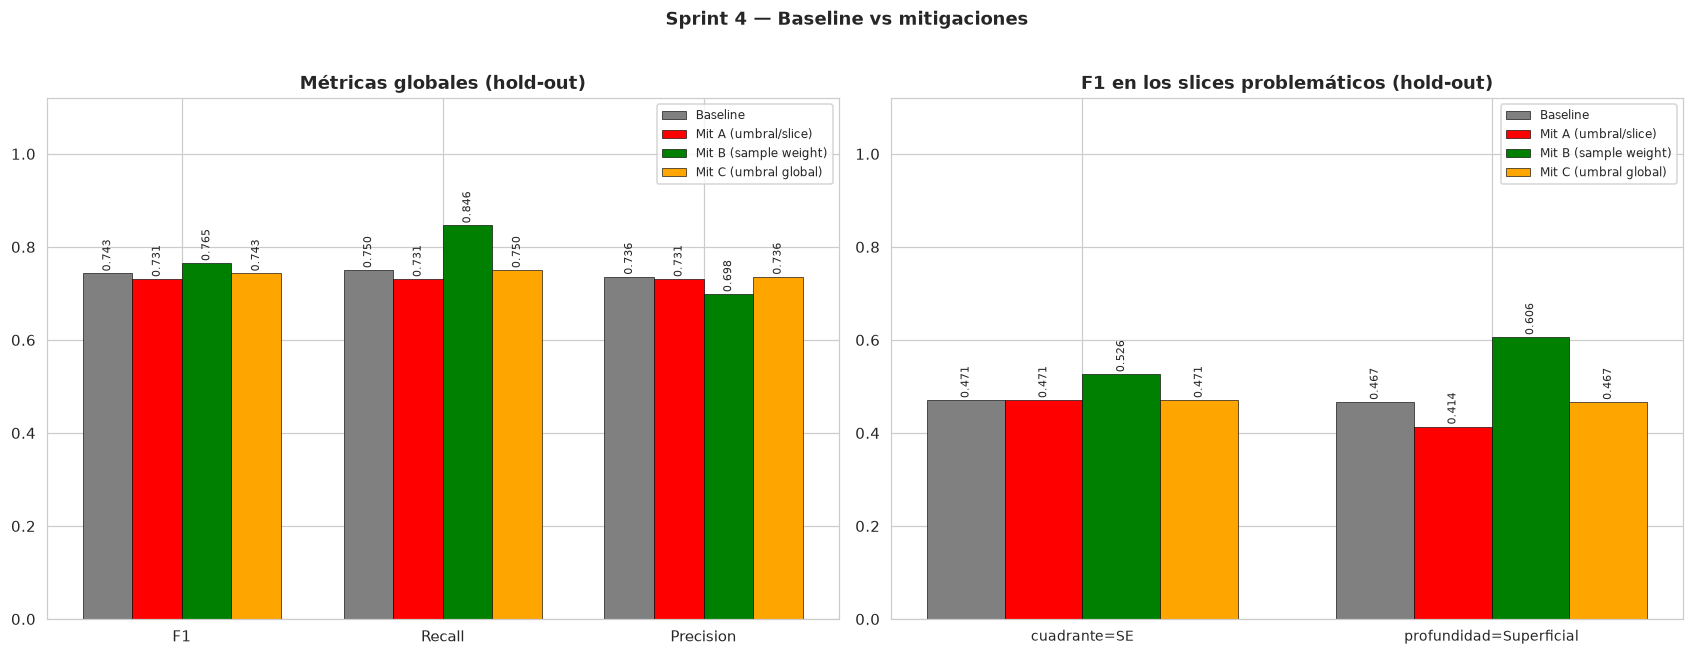

,Variante,F1 global,F1 medio slices prob.,Δ slices vs baseline,No degrada global (≤0.01),Cumple criterio
0,Mit A (umbral/slice),0.7308,0.4422,-0.0264,False,False
1,Mit B (sample weight),0.7652,0.5662,0.0976,True,True
2,Mit C (umbral global),0.7429,0.4686,0.0000,True,False


MITIGACIÓN SELECCIONADA: Mit B (sample weight)


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(15.5, 5.8))
variantes = list(preds_map.keys())
colores_v = ['gray', 'red', 'green', 'orange']

# panel 1: metricas globales
mets = ['F1', 'Recall', 'Precision']
x = np.arange(len(mets)); wdt = 0.19
for j, (nom, col) in enumerate(zip(variantes, colores_v)):
    vals = [comp.loc[nom, m] for m in mets]
    axes[0].bar(x + (j - 1.5) * wdt, vals, wdt, label=nom, color=col, edgecolor='black', lw=0.4)
    for xi, v in zip(x + (j - 1.5) * wdt, vals):
        axes[0].text(xi, v + 0.01, f'{v:.3f}', ha='center', fontsize=7, rotation=90)
axes[0].set_xticks(x); axes[0].set_xticklabels(mets); axes[0].set_ylim(0, 1.12)
axes[0].set_title('Métricas globales (hold-out)', fontweight='bold'); axes[0].legend(fontsize=8)

# panel 2: F1 en los slices problematicos
piv = comp_slices.pivot(index='Slice', columns='Variante', values='F1')[variantes]
x2 = np.arange(len(piv))
for j, (nom, col) in enumerate(zip(variantes, colores_v)):
    axes[1].bar(x2 + (j - 1.5) * wdt, piv[nom], wdt, label=nom, color=col, edgecolor='black', lw=0.4)
    for xi, v in zip(x2 + (j - 1.5) * wdt, piv[nom]):
        axes[1].text(xi, v + 0.01, f'{v:.3f}', ha='center', fontsize=7, rotation=90)
axes[1].set_xticks(x2); axes[1].set_xticklabels(piv.index, fontsize=9); axes[1].set_ylim(0, 1.12)
axes[1].set_title('F1 en los slices problemáticos (hold-out)', fontweight='bold'); axes[1].legend(fontsize=8)
plt.suptitle('Sprint 4 — Baseline vs mitigaciones', fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig('outputs_sprint4/experimento.png', bbox_inches='tight'); plt.show()

# ---- seleccion: mejora slices problematicos sin degradar el global mas de 0.01 ----
f1_slices_base = comp_slices[comp_slices.Variante == 'Baseline']['F1'].mean()
mejores = []
for nom in variantes[1:]:
    f1_sl = comp_slices[comp_slices.Variante == nom]['F1'].mean()
    ok_global = comp.loc[nom, 'F1'] >= F1_GLOBAL - 0.01
    mejores.append({'Variante': nom, 'F1 global': comp.loc[nom, 'F1'],
                    'F1 medio slices prob.': round(f1_sl, 4),
                    'Δ slices vs baseline': round(f1_sl - f1_slices_base, 4),
                    'No degrada global (≤0.01)': ok_global,
                    'Cumple criterio': ok_global and (f1_sl > f1_slices_base)})
sel = pd.DataFrame(mejores)
display(sel)
elegibles = sel[sel['Cumple criterio']]
if len(elegibles):
    GANADORA = elegibles.sort_values('F1 medio slices prob.', ascending=False).iloc[0]['Variante']
    print(f'MITIGACIÓN SELECCIONADA: {GANADORA}')
else:
    GANADORA = 'Ninguna (se mantiene el baseline)'
    print('Ninguna mitigación cumple el criterio → se mantiene el baseline del Sprint 3')
sel.to_csv('outputs_sprint4/seleccion_mitigacion.csv', index=False)

## Resumen

In [29]:
resumen4 = {
    'modelo_base': RESUMEN_S3['ganador'],
    'f1_global_baseline': round(F1_GLOBAL, 4),
    'n_slices_evaluados': int(len(tabla_slices)),
    'slices_problematicos': [f"{r['Slice']}={r['Categoría']} (F1={r['F1']}, "
                             f"{'significativo' if r['significativo'] else 'a vigilar'})"
                             for _, r in TOP2.iterrows()],
    'mitigacion_seleccionada': GANADORA,
    'metricas_finales': {k: round(v, 4) for k, v in
                         (MET_BASE if GANADORA.startswith('Ninguna') else
                          {'Mit A (umbral/slice)': MET_A, 'Mit B (sample weight)': MET_B,
                           'Mit C (umbral global)': MET_C}[GANADORA]).items()}}
with open('outputs_sprint4/resumen_sprint4.json', 'w') as f:
    json.dump(resumen4, f, indent=2, ensure_ascii=False)

print('════════════ RESUMEN SPRINT 4 ════════════')
print(f'Modelo evaluado: {RESUMEN_S3["ganador"]} (F1 global = {F1_GLOBAL:.4f})')
print(f'\nSlices problemáticos accionables (n≥30, pos≥5):')
for _, r in TOP2.iterrows():
    print(f'  - {r["Slice"]} = {r["Categoría"]}: F1={r["F1"]:.4f} '
          f'(Δ={r["Δ F1 vs global"]:+.4f}, IC95=[{r["IC95_inf"]:.3f}, {r["IC95_sup"]:.3f}], '
          f'{"significativo" if r["significativo"] else "a vigilar"})')
print(f'\nMitigación seleccionada: {GANADORA}')
print('\nEvolución del proyecto:')
print(f'  Sprint 1 = {RESUMEN_S2["f1_sprint1"]:.4f} → Sprint 2 = {RESUMEN_S2["f1_final"]:.4f} → '
      f'Sprint 3 = {RESUMEN_S3["f1_final"]:.4f} → Sprint 4 (baseline verificado) = {F1_GLOBAL:.4f}')

════════════ RESUMEN SPRINT 4 ════════════
Modelo evaluado: XGBoost (Mejor set  + params XGB + cluster) (F1 global = 0.7429)

Slices problemáticos accionables (n≥30, pos≥5):
  - profundidad = Superficial: F1=0.4667 (Δ=-0.2762, IC95=[0.214, 0.667], significativo)
  - cuadrante = SE: F1=0.4706 (Δ=-0.2723, IC95=[0.133, 0.728], significativo)

Mitigación seleccionada: Mit B (sample weight)

Evolución del proyecto:
  Sprint 1 = 0.7130 → Sprint 2 = 0.8036 → Sprint 3 = 0.7429 → Sprint 4 (baseline verificado) = 0.7429
